# Telco-Customer-Churn

# 1) load Dataset

In [251]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv(r"C:\Rohit Personal\DA and DS\ML\Telco Customer Churn\WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 2) Data Understanding

In [252]:
df.head()  # For Top 5 rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [253]:
df.tail() # For Bottom 5 rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [254]:
df.info()    # Information of the Data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [255]:
df.shape   # Rows=7045 , columns=21

(7043, 21)

In [256]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

# 3) Data Cleaning

In [257]:
df.duplicated().sum()     # No Duplicated recordes

np.int64(0)

In [258]:
# Missing Values
df.isnull().sum()       # No null values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [259]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') #TotalCharges is stored as object, even though it contains numerical values.

In [260]:
df['TotalCharges'].dtype

dtype('float64')

# 4) EDA — Exploratory Data Analysis

In [261]:
import matplotlib.pyplot as plt
import seaborn as sns

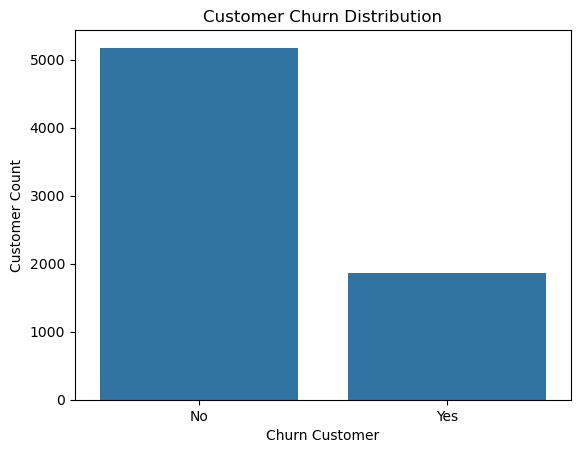

In [262]:
sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Distribution')
plt.xlabel('Churn Customer')
plt.ylabel('Customer Count')
plt.show()

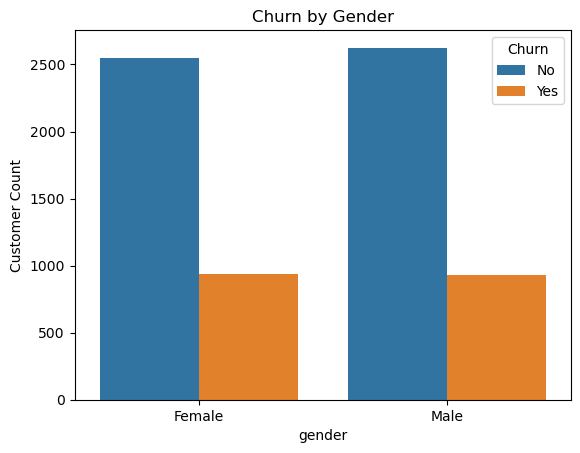

In [263]:
sns.countplot(x='gender',hue='Churn',data=df)
plt.title('Churn by Gender')
plt.ylabel('Customer Count')
plt.show()

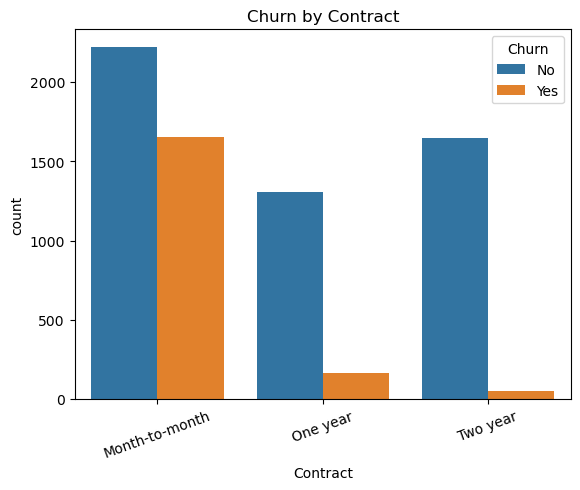

In [264]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=20)
plt.title('Churn by Contract')
plt.show()

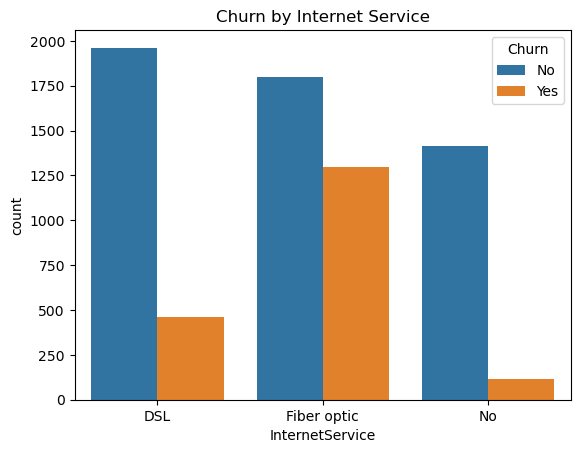

In [265]:
sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title('Churn by Internet Service')
plt.show()

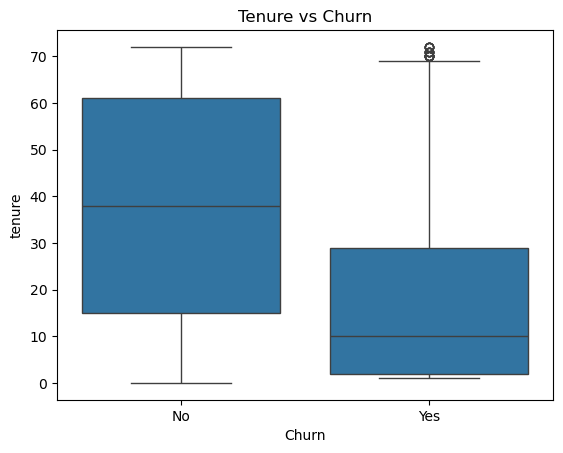

In [266]:
sns.boxplot(x='Churn', y='tenure', data=df)

plt.title('Tenure vs Churn')
plt.show()

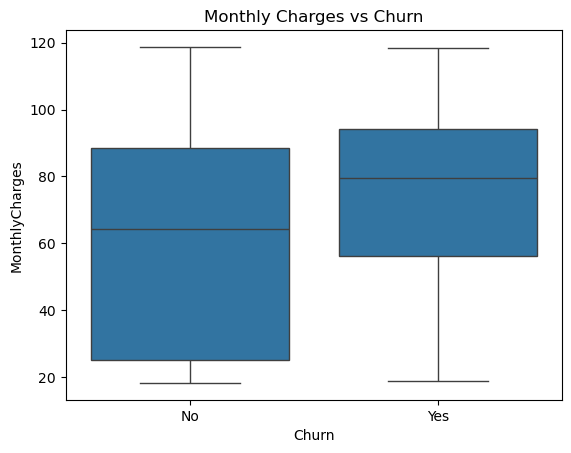

In [267]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

# 5) Categorical Encoding

In [268]:
# Label Encoder
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [269]:
df['churn_encoded']=df['Churn'].map({"No":0,"Yes":1})
df['churn_encoded'].head()

0    0
1    0
2    1
3    0
4    1
Name: churn_encoded, dtype: int64

In [270]:
df_model['TotalCharges'] = pd.to_numeric(
    df_model['TotalCharges'],
    errors='coerce'
)

In [271]:
df_model['TotalCharges'] = df_model['TotalCharges'].fillna(
    df_model['TotalCharges'].median()
)

In [272]:
df_encoded = pd.get_dummies(
    df_model,
    columns=df_model.select_dtypes(include='object').columns,
    drop_first=True
)

In [273]:
df_encoded = df_encoded.astype(int)

In [274]:
print("Shape:", df_encoded.shape)
print("Missing values:", df_encoded.isnull().sum().sum())
print("Object columns:", df_encoded.select_dtypes(include='object').shape[1])

Shape: (7043, 32)
Missing values: 0
Object columns: 0


In [275]:
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,churn_encoded,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29,29,0,0,1,0,0,1,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56,1889,0,1,0,0,1,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53,108,1,1,0,0,1,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42,1840,0,1,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70,151,1,0,0,0,1,0,...,0,0,0,0,0,1,0,1,0,1


# 6)Train-Test Split

In [317]:
X = df_encoded.drop(
    columns=['churn_encoded', 'Churn_Yes'],
    errors='ignore'
)

y = df_encoded['churn_encoded']

In [350]:
print(X.shape)
print(X.isnull().sum().sum())
print([col for col in X.columns if 'churn' in col.lower()])

(7043, 30)
0
[]


In [360]:
from sklearn.model_selection import train_test_split

# 7)Feature Scaling

In [372]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [373]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [374]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [376]:
y_pred=model.predict(x_test_scaled)
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

# 8)Confusion Matrix

In [377]:
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

In [381]:
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.8069552874378992

In [382]:
print(confusion_matrix(y_test,y_pred))

[[925 110]
 [162 212]]


In [383]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



# 9)5-Fold Cross-Validation

In [384]:
from sklearn.model_selection import cross_val_score

In [385]:
cv_score=cross_val_score(
    model,
    x_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)
cv_score

array([0.82874889, 0.80301686, 0.80745342, 0.79236912, 0.79218472])

# 10)GridSearchCV

In [386]:
model=LogisticRegression()
penalty=['l1','l2','elasticnet']
solver=['newton-cg','lbfgs','liblinear','sag','saga']
max_iter=[100,150,200,250]
c_value=[100,10,1.0,0.1,0.01]

In [387]:
parameter=dict(penalty=penalty,solver=solver,max_iter=max_iter,C=c_value)

In [388]:
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold()

In [389]:
# GridSearchCV:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(estimator=model,param_grid=parameter,cv=cv,n_jobs=-1)
grid.fit(x_train_scaled,y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'max_iter': [100, 150, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [390]:
grid.best_params_

{'C': 1.0, 'max_iter': 100, 'penalty': 'l2', 'solver': 'lbfgs'}

In [391]:
grid.best_score_

np.float64(0.8047546024356148)

In [392]:
y_pred_grid=grid.predict(x_test_scaled)
y_pred_grid

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

In [393]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [394]:
accuracy_grid=accuracy_score(y_test,y_pred_grid)
accuracy_grid

0.8069552874378992

In [395]:
print(confusion_matrix(y_test,y_pred_grid))
print()
print(classification_report(y_test,y_pred_grid))

[[925 110]
 [162 212]]

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



# 11)RandomizedSearchCV

In [396]:
from sklearn.model_selection import RandomizedSearchCV

In [397]:
model=LogisticRegression()
rs=RandomizedSearchCV(estimator=model,param_distributions=parameter,cv=5,scoring='accuracy')
rs.fit(x_train_scaled,y_train)

,estimator,LogisticRegression()
,param_distributions,"{'C': [100, 10, ...], 'max_iter': [100, 150, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [398]:
rs.best_params_

{'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 150, 'C': 100}

In [399]:
rs.best_score_

np.float64(0.8040444380702315)

In [400]:
y_pred_rs=rs.predict(x_test_scaled)
y_pred_rs

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

In [401]:
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report

In [402]:
accuracy_rs=accuracy_score(y_test,y_pred_rs)
accuracy_rs

0.8026969481902059

In [403]:
print(confusion_matrix(y_test,y_pred_rs))
print()
print(classification_report(y_test,y_pred_rs))

[[923 112]
 [166 208]]

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



# 12)Compare Models

In [404]:
print('Logistic :',accuracy_score(y_test,y_pred))
print('GridSearchCV :',accuracy_score(y_test,y_pred_grid))
print('RandomizedSearchCV :',accuracy_score(y_test,y_pred_rs))

Logistic : 0.8069552874378992
GridSearchCV : 0.8069552874378992
RandomizedSearchCV : 0.8026969481902059


Conclusion: The Telco Customer Churn dataset was successfully analyzed and preprocessed. Logistic Regression was used to predict customer churn. Hyperparameter tuning was performed using GridSearchCV and RandomizedSearchCV, and the models were evaluated using Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and 5-Fold Cross-Validation. The best-performing model was selected based on test-set performance and cross-validation results. Finally, training and testing performance were compared to check for overfitting. The final model can help identify customers who are more likely to churn and can support customer-retention strategies.